# Empresa de Productos Alimenticios. 

###### Objetivo: Investigar el comportamineto del usuario.

### Paso 1. Abrir el archivo de datos y leer la información general.

#### Importar librerias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math as mth
import scipy.stats as stats
import datetime as dt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

#### Leer el archivo.

In [2]:
df_data=pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

In [3]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [4]:
df_data.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


### Paso 2. Preparar los datos para el análisis.

In [5]:
# 2.1 Reenombramos las columnas.
new_name_columns={'EventName':'nombre_evento','DeviceIDHash':'id_usuario','EventTimestamp':'hora_evento','ExpId':'id_exp'}
df_data=df_data.rename(columns=new_name_columns)

# Comprobamos cambio.
print(df_data.head())


             nombre_evento           id_usuario  hora_evento  id_exp
0         MainScreenAppear  4575588528974610257   1564029816     246
1         MainScreenAppear  7416695313311560658   1564053102     246
2  PaymentScreenSuccessful  3518123091307005509   1564054127     248
3         CartScreenAppear  3518123091307005509   1564054127     248
4  PaymentScreenSuccessful  6217807653094995999   1564055322     248


In [6]:
# 2.2.1 Comprobamos para tipo de datos.
print(df_data.dtypes)
# Debemos cambiar el tipo de dato de la columna 'hora_evento'.
# Trabjaremos con la columna 'hora_evento' en el punto 2.3.

# 2.2.2 Compromos para valores ausentes.
df_data.isnull().sum() 

nombre_evento    object
id_usuario        int64
hora_evento       int64
id_exp            int64
dtype: object


nombre_evento    0
id_usuario       0
hora_evento      0
id_exp           0
dtype: int64

In [7]:
# 2.3.1 Agregamos la columna de fecha y hora.
df_data['fecha_hora_evento']=pd.to_datetime(df_data['hora_evento'], unit='s')

# 2.3.2 Agregamos una columna que contenga solamente la fecha.
df_data['fecha']=df_data['fecha_hora_evento'].dt.date

# Comprobamos cambios y creación de las columnas.
df_data.head()

,nombre_evento,id_usuario,hora_evento,id_exp,fecha_hora_evento,fecha
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


### Paso 3. Estudiar y comprobar los datos.

#### 3.1 ¿Cuántos eventos hay en los registros?

In [8]:
# Contamos el número de eventos únicos.
print("""Número de eventos únicos.""")
print(df_data['nombre_evento'].nunique())
print()
# Mostramos el nombre de los eventos únicos.
print("""Nombre de eventos únicos.""")
print(df_data['nombre_evento'].unique())

Número de eventos únicos.
5

Nombre de eventos únicos.
['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']


#### 3.2 ¿Cuántos usuarios hay en los registros?.

In [9]:
# Contamos el número de usuarios únicos. 
print("""Número de usuarios únicos.""")
print(df_data['id_usuario'].nunique())
print()

Número de usuarios únicos.
7551



#### 3.3 ¿Cuál es el promedio de eventos por usuario?.

In [10]:
# Agrupamos la columna evento por usuario único y contamos para cada usuario unico el número de eventos.
# asignamos a una variable.
cuenta_evento_usuario=df_data.groupby('id_usuario')['nombre_evento'].count()
# Calcualamos el promedió de eventos por usuarios.
promedio_evento_usuatio=cuenta_evento_usuario.mean()
print("""Promedio de eventos por Usuario.""")
print(promedio_evento_usuatio)


Promedio de eventos por Usuario.
32.33028737915508


#### 3.4 ¿Qué periodo de tiempo cubren los datos? Encuentra la fecha máxima y mínima. Traza un histograma por fecha y hora. ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo? Los eventos más antiguos podrían terminar en los registros de algunos usuarios por razones técnicas y esto podría sesgar el panorama general. Encuentra el momento en el que los datos comienzan a estar completos e ignora la sección anterior. ¿Qué periodo representan realmente los datos?


In [11]:
# Buscamos la fechas más reciente y la más antigua.
print("""Fecha más Antigua:""")
fecha_minima=df_data['fecha'].min()
print(fecha_minima)
print()
print("""Fecha más Reciente:""")
fecha_maxima=df_data['fecha'].max()
print(fecha_maxima)

Fecha más Antigua:
2019-07-25

Fecha más Reciente:
2019-08-07


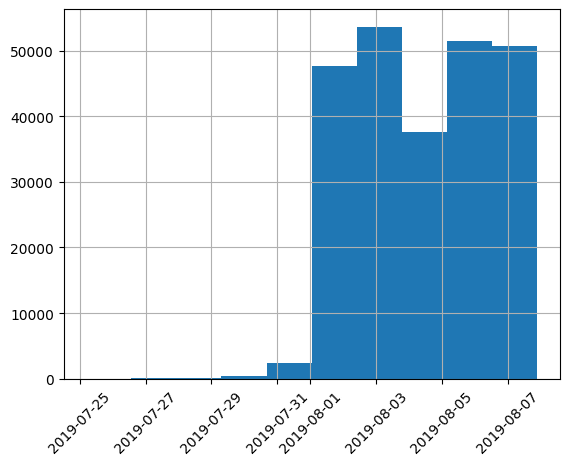

In [12]:
# Trazamos un histograma por fecha y hora.
df_data['fecha_hora_evento'].hist(bins=10)
plt.xticks(rotation=45)
plt.show()
# Nota: Podemos apreciar que para las fechas antes del 29 de Agosto de 2019 los datos son casi inexistentes, pudieramos solo quedarnos con los datos despues de la fecha mencionada.

Numero de eventos por día.

         fecha  número_eventos
0   2019-07-25               9
1   2019-07-26              31
2   2019-07-27              55
3   2019-07-28             105
4   2019-07-29             184
5   2019-07-30             413
6   2019-07-31            2031
7   2019-08-01           36229
8   2019-08-02           35606
9   2019-08-03           33351
10  2019-08-04           33033
11  2019-08-05           36113
12  2019-08-06           35822
13  2019-08-07           31144

Total de Eventos.
número_eventos    244126
dtype: int64

Promedio de Eventos.
número_eventos    17437.571429
dtype: float64



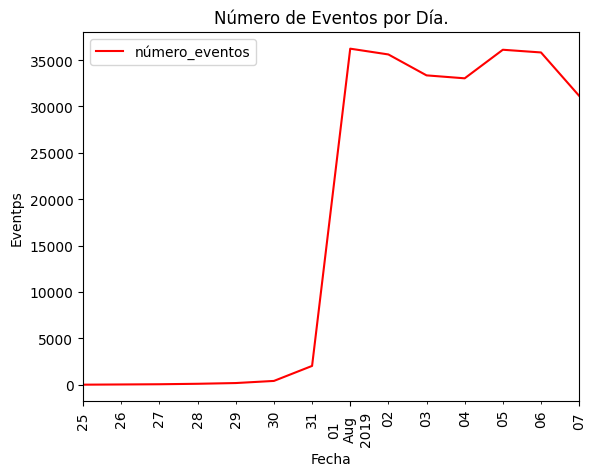

In [13]:
# Eventos por día, agrupando por fecha la columna de nombre_evento.
print("""Numero de eventos por día.""")
eventos_fecha=df_data.groupby('fecha')['nombre_evento'].count().reset_index()
new_name_columns={'fecha':'fecha','nombre_evento':'número_eventos',}
eventos_fecha=eventos_fecha.rename(columns=new_name_columns)
print()
print(eventos_fecha)
print()
# Total de eventos para el periodo antes de remover datos incompletos.
print("""Total de Eventos.""")
total_eventos_antes=eventos_fecha.sum()
print(total_eventos_antes)
print()
# Promedio de eventos para el periodo antes de remover datos incompletos.
print("""Promedio de Eventos.""")
print(eventos_fecha.mean())
eventos_fecha['fecha']=pd.to_datetime(eventos_fecha['fecha'])
print()
eventos_fecha.plot(x='fecha', y='número_eventos', legend=True,title='Número de Eventos por Día.',xlabel='Fecha',ylabel='Eventps',rot=90, color='red')
plt.show()



Total de Eventos después de datos incompletos.
241298

Promedio de Eventos después de datos incompletos.
34471.142857142855

El periodo de analisis comprende del: 2019-08-01 al 2019-08-07, en total un periodo: 7 de días.

        fecha  número_eventos
7  2019-08-01           36229
8  2019-08-02           35606
9  2019-08-03           33351
10 2019-08-04           33033
11 2019-08-05           36113
12 2019-08-06           35822
13 2019-08-07           31144


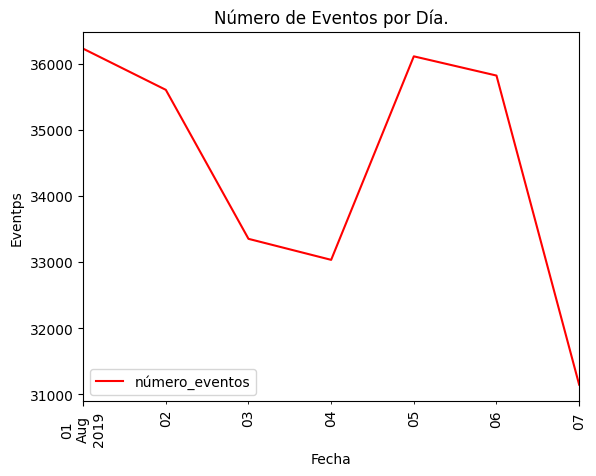

In [14]:
# Creamos el filtro para datos despues de datos incompletos.
# Fecha de corte apartir del 1 de Agosto del 2019.
fecha_corte = pd.to_datetime('2019-08-01')
eventos_despues_corte = eventos_fecha[eventos_fecha['fecha']>= fecha_corte]
print()
# Total de eventos para el periodo después de remover datos incompletos.
print("""Total de Eventos después de datos incompletos.""")
total_despues_corte = eventos_despues_corte['número_eventos'].sum()
print(total_despues_corte)
print()
# Promedio de eventos para el periodo después de remover datos incompletos.
print("""Promedio de Eventos después de datos incompletos.""")
promedio_despues_corte = eventos_despues_corte['número_eventos'].mean()
print(promedio_despues_corte)
print()
# Periodo que comprenden los datos depues del eliminar datos incompletos.
fecha_inicio=eventos_despues_corte['fecha'].dt.date.min()
fecha_final=eventos_despues_corte['fecha'].dt.date.max()
perido_dias=(fecha_final-fecha_inicio).days +1
print(f'El periodo de analisis comprende del: {fecha_inicio} al {fecha_final}, en total un periodo: {perido_dias} de días.')
print()
#Graficamos para observar los nuevos datos.
print(eventos_despues_corte)
eventos_despues_corte.plot(x='fecha', y='número_eventos', legend=True,title='Número de Eventos por Día.',xlabel='Fecha',ylabel='Eventps',rot=90, color='red')
plt.show()


In [15]:
# Filtrar datos desde el 1 de agosto de 2019, convieriendo la fecha a tipo datetime, para mejor comprension de python.
fecha_inicio_completo = pd.to_datetime('2019-08-01').date()

# Creamos un dataframe que contien solo los eventos que comienzan el 1 de Agosto de 2019.
# Ya que se se presume que anterior a esa fecha, los datos no estaban completos.
df_data_completo = df_data[df_data['fecha'] >= fecha_inicio_completo].copy()

# Convertimos la columan de fecha a tipo datetime.
df_data_completo['fecha'] = pd.to_datetime(df_data_completo['fecha'])

# Confirmamos creacion del dataframe despues de datos incompletos.
df_data_completo.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 241298 entries, 2828 to 244125
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   nombre_evento      241298 non-null  object        
 1   id_usuario         241298 non-null  int64         
 2   hora_evento        241298 non-null  int64         
 3   id_exp             241298 non-null  int64         
 4   fecha_hora_evento  241298 non-null  datetime64[ns]
 5   fecha              241298 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(3), object(1)
memory usage: 12.9+ MB


#### 3.5 ¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?

In [16]:
# Calculamos la cantidad de datos eliminados.
datos_eliminados=total_eventos_antes.iloc[0]-total_despues_corte
print(f'Número de datos eliminados: {datos_eliminados:,}')
print()
proporcion_datos_eliminados = datos_eliminados/total_eventos_antes.iloc[0]
print(f'Proporción de datos eliminados: {proporcion_datos_eliminados:.2%}')



Número de datos eliminados: 2,828

Proporción de datos eliminados: 1.16%


#### 3.6 Asegúrate de tener usuarios de los tres grupos experimentales.

Número de usuarios por cada grupo de experimento.
   id_exp  id_usuario
0     246       79425
1     247       77147
2     248       84726


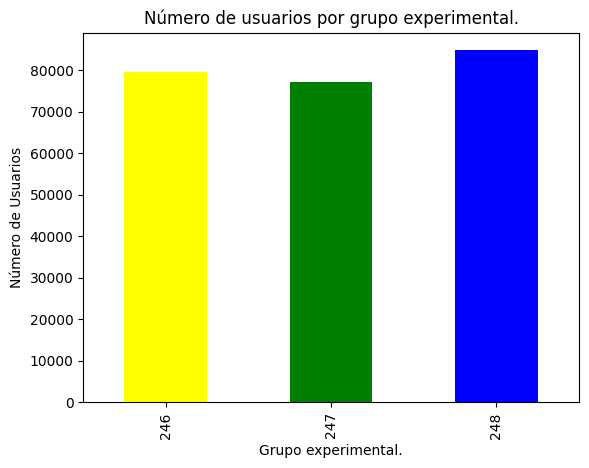

In [17]:
# Agrupamos por identificador de experimento la columna de id_usuarios, para conocer la cantida de usuarios por experimento.
grupos_numero=df_data_completo.groupby('id_exp')['id_usuario'].count().reset_index()
print("""Número de usuarios por cada grupo de experimento.""")
print(grupos_numero)
# Podemos apreciar que que despues de eliminar datos incompletos aún tenemos datos en los tres grupos experimentales.
# Visualizamos los datos.
colors=['yellow','green','blue']
grupos_numero.plot(x='id_exp', y='id_usuario',legend=False, kind='bar', color=colors ,title='Número de usuarios por grupo experimental.',xlabel='Grupo experimental.',ylabel='Número de Usuarios')
plt.show()       


### Paso 4. Estudiar el embudo de eventos.

#### 4.1 Observa qué eventos hay en los registros y su frecuencia de suceso. Ordénalos por frecuencia.

Eventos disponibles:

['Tutorial' 'MainScreenAppear' 'OffersScreenAppear' 'CartScreenAppear'
 'PaymentScreenSuccessful']

Frecuencia de Eventos.

MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: nombre_evento, dtype: int64


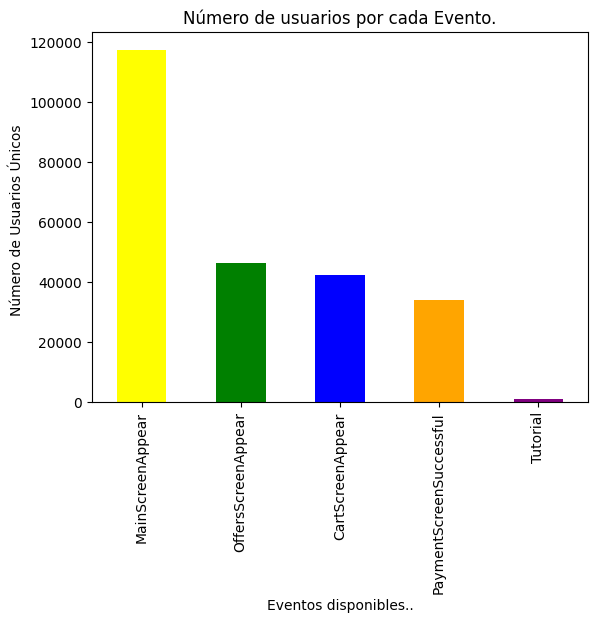

In [18]:
# Encontramos eventos únicos.
eventos_unicos=df_data_completo['nombre_evento'].unique()
print("Eventos disponibles:")
print()
print(eventos_unicos)
print()
# Calculamos la frecuencia de los eventos.
frecuencia_eventos=df_data_completo['nombre_evento'].value_counts().sort_values(ascending=False)
print("Frecuencia de Eventos.")
print()
print(frecuencia_eventos)
# Visualizamos los datos.
colors=['yellow','green','blue','orange', 'purple']
frecuencia_eventos.plot(x='nombre_evento', y='id_usuario',legend=False, kind='bar', color=colors ,title='Número de usuarios por cada Evento.',xlabel='Eventos disponibles..',ylabel='Número de Usuarios Únicos ')
plt.show()

#### 4.2  Encuentra la cantidad de usuarios que realizaron cada una de estas acciones. Ordena los eventos por el número de usuarios. Calcula la proporción de usuarios que realizaron la acción al menos una vez.

In [19]:
# Agrupamos por cada evento la columna 'id_usuario', para saber la cantidad de usuarios únicos en cada etapa.
usuarios_por_evento=df_data_completo.groupby('nombre_evento')['id_usuario'].nunique().sort_values(ascending=False).reset_index()
print("""Cantidad de usuarios únicos en cada etapa del proceso.""")
print()
print(usuarios_por_evento)
# Calculamos la proporcion para cada etapa del proceso.
total_usuarios=usuarios_por_evento['id_usuario'].sum()
print(f'Total de Usuarios únicos: {total_usuarios}')
print()
print(f'Proporción de Usuarios por cada evento.')
usuarios_por_evento['proporción']=(usuarios_por_evento['id_usuario']/total_usuarios)*100
print()
print(usuarios_por_evento[['nombre_evento','proporción']])

Cantidad de usuarios únicos en cada etapa del proceso.

             nombre_evento  id_usuario
0         MainScreenAppear        7419
1       OffersScreenAppear        4593
2         CartScreenAppear        3734
3  PaymentScreenSuccessful        3539
4                 Tutorial         840
Total de Usuarios únicos: 20125

Proporción de Usuarios por cada evento.

             nombre_evento  proporción
0         MainScreenAppear   36.864596
1       OffersScreenAppear   22.822360
2         CartScreenAppear   18.554037
3  PaymentScreenSuccessful   17.585093
4                 Tutorial    4.173913


#### 4.3 ¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia? No es necesario tenerlas en cuenta al calcular el embudo.

In [20]:
# Encontramos eventos únicos.
eventos_unicos=df_data_completo['nombre_evento'].unique()
print("Eventos disponibles:")
print()
print(eventos_unicos)

Eventos disponibles:

['Tutorial' 'MainScreenAppear' 'OffersScreenAppear' 'CartScreenAppear'
 'PaymentScreenSuccessful']


##### Considero que los usuarios relizan las siguientes acciones. Acceden a la pagina principal (MainScreenAppear), si el cliente lo desea puede usar el Tutorial (Tutorial), sino observan las ofertas disponibles ('OffersScreenAppear'), si selecciona una oferta la agregan al carrito ('CartScreenAppear') y para finalizar pagar los productos seleccionados en la ventana de pago ('PaymentScreenSuccessful').

#### 4.4 Utiliza el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente.

In [21]:
# 4.4.1 Calculamos embudo.

# Definimos cuales eventos del proceso son relevantes para el embudo.
embudo_pasos = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

# Ordenar por usuario y tiempo, para calcular el embudo.
df_ordenado = df_data_completo.sort_values(by=['id_usuario', 'fecha'])

# Filtrar solo eventos relevantes para el embudo
df_embudo = df_ordenado[df_ordenado['nombre_evento'].isin(embudo_pasos)]

# Eliminar duplicados por usuario y evento.
df_embudo = df_embudo.drop_duplicates(subset=['id_usuario', 'nombre_evento'])

# Elaboramos una tabla dinamica para ver qué pasos completó cada usuario.
df_usuarios_eventos = df_embudo.pivot(index='id_usuario', columns='nombre_evento', values='fecha')

# Calcular proporciones secuenciales.
usuarios_main = df_usuarios_eventos.dropna(subset=['MainScreenAppear'])
usuarios_offers = usuarios_main.dropna(subset=['OffersScreenAppear'])
usuarios_cart = usuarios_offers.dropna(subset=['CartScreenAppear'])
usuarios_payment = usuarios_cart.dropna(subset=['PaymentScreenSuccessful'])

# 4.4.2 Calculamos y mostramos las proporciones.
# Calculamos y mostramos las proporciones de cada evento.
print("Usuarios en MainScreenAppear:", len(usuarios_main))
print()
print("Usuarios que pasaron a OffersScreenAppear:", len(usuarios_offers))
print()
print("Proporción Offers/Main:", len(usuarios_offers) / len(usuarios_main))
print()
print("Usuarios que pasaron a CartScreenAppear:", len(usuarios_cart))
print()
print("Proporción Cart/Offers:", len(usuarios_cart) / len(usuarios_offers))
print()
print("Usuarios que pasaron a PaymentScreenSuccessful:", len(usuarios_payment))
print()
print("Proporción Payment/Cart:", len(usuarios_payment) / len(usuarios_cart))


Usuarios en MainScreenAppear: 7419

Usuarios que pasaron a OffersScreenAppear: 4482

Proporción Offers/Main: 0.6041245450869389

Usuarios que pasaron a CartScreenAppear: 3580

Proporción Cart/Offers: 0.7987505577867023

Usuarios que pasaron a PaymentScreenSuccessful: 3429

Proporción Payment/Cart: 0.9578212290502793


#### 4.5 ¿En qué etapa pierdes más usuarios?

##### Podemos apreciar que la etapa en la que más perdimos usuarios fue entre la pantalla principal (MainScreenAppear) y la pantalla de ofertas (OffersScreenAppear), pasando de 7,419 ususarios a 4,482 usuarios, lo que representa una reducción de 40%. 

#### 4.6 ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

In [22]:
# Obtenemos los usuarios que recorrieron todos los pasos del embudo.
usuarios_completos = df_usuarios_eventos.dropna(subset=embudo_pasos)

# Total de usuarios que iniciaron el embudo.
usuarios_inicio = df_usuarios_eventos.dropna(subset=['MainScreenAppear'])

# Calcular el porcentaje.
porcentaje_completo = len(usuarios_completos) / len(usuarios_inicio) * 100

print(f" Porcentaje de usuarios que completan todo el embudo: {porcentaje_completo:.2f}%")


 Porcentaje de usuarios que completan todo el embudo: 46.22%


### Paso 5. Estudiar los resultados del experimento.

#### 5.1 ¿Cuántos usuarios hay en cada grupo?

In [23]:
# Calculamos el numero de ususarios para cada grupo.
usuarios_id_exp = df_data_completo.groupby('id_exp')['id_usuario'].nunique()
print("""Número de usuarios por grupo experimental""")
print(usuarios_id_exp)

Número de usuarios por grupo experimental
id_exp
246    2484
247    2513
248    2537
Name: id_usuario, dtype: int64


#### 5.2 Observa si hay una diferencia estadísticamente significativa entre las muestras 246 y 247.

In [24]:
# Calcumas metricas de ambos grupos.
# Para el grupo experimental 246.
df_exp_246 = df_data_completo[df_data_completo['id_exp']==246].reset_index()
users_main_sc_246=df_exp_246[df_exp_246['nombre_evento']=='MainScreenAppear']['id_usuario'].nunique()
print("""Total de Ususarios que visitaron la página del grupo 246""")
print(users_main_sc_246)
users_payment_sc_246=df_exp_246[df_exp_246['nombre_evento']=='PaymentScreenSuccessful']['id_usuario'].nunique()
print()
print("""Total de Ususarios que Realizaron un pedido del grupo 246""")
print(users_payment_sc_246)
print()
# Para el grupo experimental 247.
df_exp_247 = df_data_completo[df_data_completo['id_exp']==247].reset_index()
users_main_sc_247=df_exp_247[df_exp_247['nombre_evento']=='MainScreenAppear']['id_usuario'].nunique()
print("""Total de Ususarios que visitaron la página del grupo 247""")
print(users_main_sc_247)
users_payment_sc_247=df_exp_247[df_exp_247['nombre_evento']=='PaymentScreenSuccessful']['id_usuario'].nunique()
print()
print("""Total de Ususarios que Realizaron un pedido del grupo 247""")
print(users_payment_sc_247)
print()

print("""
    - H₀ (hipótesis nula): las tasas de conversión de ambos grupos son iguales.
    - H₁ (hipótesis alternativa): las tasas de conversión son diferentes.
""")

print("""Z-test de proporciones (para tasa de conversión)""")
observaciones = [users_main_sc_246, users_main_sc_247]  # Número de usuarios que visitaron la tienda para ambos grupos.
exitos = [users_payment_sc_246, users_payment_sc_247] # Número de ususarios que realizaron pedidos para ambos grupos.
print()
# Test bilateral (por defecto)
stat, pval = proportions_ztest(count=exitos, nobs=observaciones)
print(f"Valor alfa: 0.05")
print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")
print()

Total de Ususarios que visitaron la página del grupo 246
2450

Total de Ususarios que Realizaron un pedido del grupo 246
1200

Total de Ususarios que visitaron la página del grupo 247
2476

Total de Ususarios que Realizaron un pedido del grupo 247
1158


    - H₀ (hipótesis nula): las tasas de conversión de ambos grupos son iguales.
    - H₁ (hipótesis alternativa): las tasas de conversión son diferentes.

Z-test de proporciones (para tasa de conversión)

Valor alfa: 0.05
Z-statistic: 1.5529
P-value: 0.1204



##### Podemos apreciar que el p-value es mayor que que el valor alfa por lo tanto no hay evidencia estadísticamente significativa para rechazar la hipótesis nula, lo que se traduce en que no hay diferencia significativa entre la tasa de conversión de los grupos experimentales 246 y 247, lo cual es el resultado deseado ya que al realizar un test A/A, ambos grupos deberian comportarte de igual forma.  

#### 5.3 Selecciona el evento más popular. En cada uno de los grupos de control, encuentra la cantidad de usuarios que realizaron esta acción. Encuentra su proporción.

In [25]:
# Con esta función econtramos el evento más popular en cada grupo de control, la cantidad de usuarios que realizan el evento y las proporcion entre eventos.
def eventos_populares(grupos):
    resultados = []

    for grupo in grupos:

        # DataFrame grupo 246.
        df_exp_grupo = df_data_completo[df_data_completo['id_exp']==grupo].reset_index()
        
        # Identificamos el numero de usuarios unicos para cada evento.
        _grupo_events=df_exp_grupo.groupby('nombre_evento')['id_usuario'].nunique().reset_index()
    
        # Identificamos el evento más concurrido.
        top_grupo_event=_grupo_events.loc[_grupo_events['id_usuario'].idxmax()]
        print(f'Grupo Experimental: {grupo}')
        print(f"Evento más popular: {top_grupo_event['nombre_evento']} ({top_grupo_event['id_usuario']} usuarios únicos)")

        # Definimos cuales eventos del proceso son relevantes para el embudo.
        embudo_pasos = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
        
        # Ordenar por usuario y tiempo, para calcular el embudo.
        df_ordenado = df_exp_grupo.sort_values(by=['id_usuario', 'fecha'])
        
        # Filtrar solo eventos relevantes para el embudo.
        df_embudo = df_ordenado[df_ordenado['nombre_evento'].isin(embudo_pasos)]
        
        # Eliminar duplicados por usuario y evento.
        df_embudo = df_embudo.drop_duplicates(subset=['id_usuario', 'nombre_evento'])
        
        # Elaboramos una tabla dinamica para ver qué pasos completó cada usuario.
        df_usuarios_eventos = df_embudo.pivot(index='id_usuario', columns='nombre_evento', values='fecha')
        
        # Calcular proporciones secuenciales.
        usuarios_main = df_usuarios_eventos.dropna(subset=['MainScreenAppear'])
        usuarios_offers = usuarios_main.dropna(subset=['OffersScreenAppear'])
        usuarios_cart = usuarios_offers.dropna(subset=['CartScreenAppear'])
        usuarios_payment = usuarios_cart.dropna(subset=['PaymentScreenSuccessful'])
        
        # Asignamos la longitud de cada dataframe anterio a una variable para el calculo de la proporción.
        total_main = len(usuarios_main)
        total_offers = len(usuarios_offers)
        total_cart = len(usuarios_cart)
        total_payment = len(usuarios_payment)
        
        # Calculamos y mostramos las proporciones de cada evento.
        print("Usuarios en MainScreenAppear:", len(usuarios_main))
        print("Usuarios que pasaron a OffersScreenAppear:", len(usuarios_offers))
        print("Proporción Offers/Main:", len(usuarios_offers) / len(usuarios_main))
        print("Usuarios que pasaron a CartScreenAppear:", len(usuarios_cart))
        print("Proporción Cart/Offers:", len(usuarios_cart) / len(usuarios_offers))
        print("Usuarios que pasaron a PaymentScreenSuccessful:", len(usuarios_payment))
        print("Proporción Payment/Cart:", len(usuarios_payment) / len(usuarios_cart))
        print()
        resultados.append({
            'grupo': grupo,
            'evento_mas_popular': top_grupo_event['nombre_evento'],
            'usuarios_main': total_main,
            'usuarios_offers': total_offers,
            'usuarios_cart': total_cart,
            'usuarios_payment': total_payment,
            'offers/main': total_offers / total_main,
            'cart/offers': total_cart / total_offers,
            'payment/cart': total_payment / total_cart
        })
    return pd.DataFrame(resultados)

In [26]:
# Aplicamos la función para nuestro test A/A grupos 246 y 247.
grupo = [246, 247]
df_resultados = eventos_populares(grupo)
print(f"Información en un Dataframe:")
print(df_resultados)

Grupo Experimental: 246
Evento más popular: MainScreenAppear (2450 usuarios únicos)
Usuarios en MainScreenAppear: 2450
Usuarios que pasaron a OffersScreenAppear: 1509
Proporción Offers/Main: 0.6159183673469387
Usuarios que pasaron a CartScreenAppear: 1221
Proporción Cart/Offers: 0.8091451292246521
Usuarios que pasaron a PaymentScreenSuccessful: 1166
Proporción Payment/Cart: 0.954954954954955

Grupo Experimental: 247
Evento más popular: MainScreenAppear (2476 usuarios únicos)
Usuarios en MainScreenAppear: 2476
Usuarios que pasaron a OffersScreenAppear: 1484
Proporción Offers/Main: 0.5993537964458805
Usuarios que pasaron a CartScreenAppear: 1184
Proporción Cart/Offers: 0.7978436657681941
Usuarios que pasaron a PaymentScreenSuccessful: 1125
Proporción Payment/Cart: 0.950168918918919

Información en un Dataframe:
   grupo evento_mas_popular  usuarios_main  usuarios_offers  usuarios_cart  \
0    246   MainScreenAppear           2450             1509           1221   
1    247   MainScreenAp

In [27]:
# Creamos una función que calcula la significancia estadística entre la tasa de conversion entre dos grupos experimentales.
# Muestras si existe o no existe significaancia estadistica.

def significancia_estadística (grupo_1,grupo_2,alpha):
    
    # Creamos el filtro para conservar la información  de grupo 1.
    print(f"Para el grupo experimental: {grupo_1}")
    print()
    df_exp_grupo_1 = df_data_completo[df_data_completo['id_exp']==grupo_1].reset_index()
   
    # Encontramos el número de vistas para el grupo 1.
    users_main_sc_grupo_1=df_exp_grupo_1[df_exp_grupo_1['nombre_evento']=='MainScreenAppear']['id_usuario'].nunique()
    print(f"Total de Usuarios que visitaron la página del grupo:")
    print(users_main_sc_grupo_1)
    
    # Encontramos el número de ordenes del grupo 1.
    users_payment_sc_grupo_1=df_exp_grupo_1[df_exp_grupo_1['nombre_evento']=='PaymentScreenSuccessful']['id_usuario'].nunique()
    print()
    print(f"Total de Usuarios que Realizaron un pedido del grupo: ")
    print(users_payment_sc_grupo_1)
    print()
    
    # Creamos el filtro para conservar la información  de grupo 2.
    print(f"Para el grupo experimental: {grupo_2}")
    print()
    df_exp_grupo_2 = df_data_completo[df_data_completo['id_exp']==grupo_2].reset_index()
    
    # Encontramos el número de vistas para el grupo 1.
    users_main_sc_grupo_2=df_exp_grupo_2[df_exp_grupo_2['nombre_evento']=='MainScreenAppear']['id_usuario'].nunique()
    print(f"Total de Ususarios que visitaron la página del grupo:")
    print(users_main_sc_grupo_2)
    
    # Encontramos el número de ordenes del grupo 2.
    users_payment_sc_grupo_2=df_exp_grupo_2[df_exp_grupo_2['nombre_evento']=='PaymentScreenSuccessful']['id_usuario'].nunique()
    print()
    print(f"Total de Ususarios que Realizaron un pedido del grupo:")
    print(users_payment_sc_grupo_2)
    print()
   
    # Mostramos tasa de conversión.
    conversion_grupo_1=users_payment_sc_grupo_1/users_main_sc_grupo_1
    print(f"Tasa de Conversión Grupo {grupo_1}")
    print(f"{(conversion_grupo_1*100):.2f} %")
    conversion_grupo_2=users_payment_sc_grupo_2/users_main_sc_grupo_2
    print()
    print(f"Tasa de Conversión Grupo {grupo_2}") 
    print(f"{(conversion_grupo_2*100):.2f} %")
    print()
    # Calculamos desviacion estándar.
    p_pool = (users_payment_sc_grupo_1 + users_payment_sc_grupo_2) / (users_main_sc_grupo_1 + users_main_sc_grupo_2)

    se = (p_pool * (1 - p_pool) * (1/users_main_sc_grupo_1 + 1/users_main_sc_grupo_2)) ** 0.5
    print(f"Desviación estándar combinada (SE): {se:.6f}")
    print()
    
    print(f"Calculamos la significancia estadística")    
    print("""
        - H₀ (hipótesis nula): las tasas de conversión de ambos grupos son iguales.
        - H₁ (hipótesis alternativa): las tasas de conversión son diferentes.
        """)
        
    print("""Z-test de proporciones (para tasa de conversión)""")
    observaciones = [users_main_sc_grupo_1, users_main_sc_grupo_2]  # Número de usuarios que visitaron la tienda para ambos grupos.
    exitos = [users_payment_sc_grupo_1, users_payment_sc_grupo_2] # Número de ususarios que realizaron pedidos para ambos grupos.
    print()
    
    # Test bilateral (por defecto)
    stat, pval = proportions_ztest(count=exitos, nobs=observaciones)
    alpha=alpha
    print(f"Valor alfa: {alpha}")
    print(f"Z-statistic: {stat:.4f}")
    print(f"P-value: {pval:.4f}")
    print("Resultado:", "Diferencia significativa" if pval < alpha else "No significativa: Podemos obervar que la hipótesis nula no se rechaza, por lo tanto no hay evidencia estadistica de alguna diferencia.")

    # Tamaño del efecto (usando diferencia de proporciones estandarizada).
    effect_size = proportion_effectsize(conversion_grupo_1, conversion_grupo_2)

    # Calculamos el poder estadístico, para saber la probabilidad de caer en erro tipo II.
    analysis = NormalIndPower()
    power = analysis.power(effect_size=effect_size, nobs1=users_main_sc_grupo_1, alpha=alpha, ratio=users_main_sc_grupo_2/users_main_sc_grupo_1, alternative='two-sided')

    print(f"Poder estadístico: {power:.4f}")
    if power > 0.8: 
        print("""El poder estadistico es alto probabilidad de cometer un error tipo II es baja. """)
    else:
        print("""El poder estadistico es bajo probabilidad de cometer un error tipo II es alta. """)

In [28]:
# Calculamos y mostramos la significancia estadistica para el test A/A grupos 246 y 247.
significancia_estadística(246, 247,0.05)


Para el grupo experimental: 246

Total de Usuarios que visitaron la página del grupo:
2450

Total de Usuarios que Realizaron un pedido del grupo: 
1200

Para el grupo experimental: 247

Total de Ususarios que visitaron la página del grupo:
2476

Total de Ususarios que Realizaron un pedido del grupo:
1158

Tasa de Conversión Grupo 246
48.98 %

Tasa de Conversión Grupo 247
46.77 %

Desviación estándar combinada (SE): 0.014235

Calculamos la significancia estadística

        - H₀ (hipótesis nula): las tasas de conversión de ambos grupos son iguales.
        - H₁ (hipótesis alternativa): las tasas de conversión son diferentes.
        
Z-test de proporciones (para tasa de conversión)

Valor alfa: 0.05
Z-statistic: 1.5529
P-value: 0.1204
Resultado: No significativa: Podemos obervar que la hipótesis nula no se rechaza, por lo tanto no hay evidencia estadistica de alguna diferencia.
Poder estadístico: 0.3423
El poder estadistico es bajo probabilidad de cometer un error tipo II es alta. 


#### 5.4 Haz lo mismo para el grupo con fuentes alteradas. Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada. Compara los resultados con los resultados combinados de los grupos de control. ¿Qué conclusiones puedes sacar del experimento?.

In [29]:
# Comenzamos con aplicar nuestra función para el Test A/B.
# Aplicamos la función para nuestro test A/B grupos 246 y 248.
grupo = [246, 248]
df_resultados = eventos_populares(grupo)
print(f"Información en un Dataframe:")
print()
# Calculamos y mostramos la significancia estadistica para el test A/B grupos 246 y 248.
significancia_estadística(246, 248,0.05)

Grupo Experimental: 246
Evento más popular: MainScreenAppear (2450 usuarios únicos)
Usuarios en MainScreenAppear: 2450
Usuarios que pasaron a OffersScreenAppear: 1509
Proporción Offers/Main: 0.6159183673469387
Usuarios que pasaron a CartScreenAppear: 1221
Proporción Cart/Offers: 0.8091451292246521
Usuarios que pasaron a PaymentScreenSuccessful: 1166
Proporción Payment/Cart: 0.954954954954955

Grupo Experimental: 248
Evento más popular: MainScreenAppear (2493 usuarios únicos)
Usuarios en MainScreenAppear: 2493
Usuarios que pasaron a OffersScreenAppear: 1489
Proporción Offers/Main: 0.5972723626153229
Usuarios que pasaron a CartScreenAppear: 1175
Proporción Cart/Offers: 0.7891202149093351
Usuarios que pasaron a PaymentScreenSuccessful: 1138
Proporción Payment/Cart: 0.9685106382978723

Información en un Dataframe:

Para el grupo experimental: 246

Total de Usuarios que visitaron la página del grupo:
2450

Total de Usuarios que Realizaron un pedido del grupo: 
1200

Para el grupo experiment

In [30]:
# Comenzamos con aplicar nuestra función para el Test A/B.
# Aplicamos la función para nuestro test A/B grupos 247 y 248.
grupo = [247, 248]
df_resultados = eventos_populares(grupo)
print(f"Información en un Dataframe:")
print()
# Calculamos y mostramos la significancia estadistica para el test A/B grupos 246 y 248.
significancia_estadística(247, 248,0.05)


Grupo Experimental: 247
Evento más popular: MainScreenAppear (2476 usuarios únicos)
Usuarios en MainScreenAppear: 2476
Usuarios que pasaron a OffersScreenAppear: 1484
Proporción Offers/Main: 0.5993537964458805
Usuarios que pasaron a CartScreenAppear: 1184
Proporción Cart/Offers: 0.7978436657681941
Usuarios que pasaron a PaymentScreenSuccessful: 1125
Proporción Payment/Cart: 0.950168918918919

Grupo Experimental: 248
Evento más popular: MainScreenAppear (2493 usuarios únicos)
Usuarios en MainScreenAppear: 2493
Usuarios que pasaron a OffersScreenAppear: 1489
Proporción Offers/Main: 0.5972723626153229
Usuarios que pasaron a CartScreenAppear: 1175
Proporción Cart/Offers: 0.7891202149093351
Usuarios que pasaron a PaymentScreenSuccessful: 1138
Proporción Payment/Cart: 0.9685106382978723

Información en un Dataframe:

Para el grupo experimental: 247

Total de Usuarios que visitaron la página del grupo:
2476

Total de Usuarios que Realizaron un pedido del grupo: 
1158

Para el grupo experiment

#### 5.5 ¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente? Calcula cuántas pruebas de hipótesis estadísticas has realizado. Con un nivel de significancia estadística de 0.1, uno de cada 10 resultados podría ser falso. ¿Cuál debería ser el nivel de significancia? Si deseas cambiarlo, vuelve a ejecutar los pasos anteriores y comprueba tus conclusiones.

##### Para la prueba realizadas en el punto 5.4 se elaboraron on un valor alpha de 0.05, la prubas elaboradas en este punto se elaboran con un valor alpha de 0.1 como lo menciona la descripción del proyecto. La compracion es entre grupo 246 y 248, de igual forma entre grupo 247 y 248.  

In [31]:
# Comenzamos con aplicar nuestra función para el Test A/B.
# Aplicamos la función para nuestro test A/B grupos 246 y 248.
grupo = [246, 248]
df_resultados = eventos_populares(grupo)
print(f"Información en un Dataframe:")
print()
# Calculamos y mostramos la significancia estadistica para el test A/B grupos 246 y 248.
significancia_estadística(246, 248,0.1)

Grupo Experimental: 246
Evento más popular: MainScreenAppear (2450 usuarios únicos)
Usuarios en MainScreenAppear: 2450
Usuarios que pasaron a OffersScreenAppear: 1509
Proporción Offers/Main: 0.6159183673469387
Usuarios que pasaron a CartScreenAppear: 1221
Proporción Cart/Offers: 0.8091451292246521
Usuarios que pasaron a PaymentScreenSuccessful: 1166
Proporción Payment/Cart: 0.954954954954955

Grupo Experimental: 248
Evento más popular: MainScreenAppear (2493 usuarios únicos)
Usuarios en MainScreenAppear: 2493
Usuarios que pasaron a OffersScreenAppear: 1489
Proporción Offers/Main: 0.5972723626153229
Usuarios que pasaron a CartScreenAppear: 1175
Proporción Cart/Offers: 0.7891202149093351
Usuarios que pasaron a PaymentScreenSuccessful: 1138
Proporción Payment/Cart: 0.9685106382978723

Información en un Dataframe:

Para el grupo experimental: 246

Total de Usuarios que visitaron la página del grupo:
2450

Total de Usuarios que Realizaron un pedido del grupo: 
1200

Para el grupo experiment

In [32]:
# Comenzamos con aplicar nuestra función para el Test A/B.
# Aplicamos la función para nuestro test A/B grupos 247 y 248.
grupo = [247, 248]
df_resultados = eventos_populares(grupo)
print(f"Información en un Dataframe:")
print()
# Calculamos y mostramos la significancia estadistica para el test A/B grupos 246 y 248.
significancia_estadística(247, 248,0.1)

Grupo Experimental: 247
Evento más popular: MainScreenAppear (2476 usuarios únicos)
Usuarios en MainScreenAppear: 2476
Usuarios que pasaron a OffersScreenAppear: 1484
Proporción Offers/Main: 0.5993537964458805
Usuarios que pasaron a CartScreenAppear: 1184
Proporción Cart/Offers: 0.7978436657681941
Usuarios que pasaron a PaymentScreenSuccessful: 1125
Proporción Payment/Cart: 0.950168918918919

Grupo Experimental: 248
Evento más popular: MainScreenAppear (2493 usuarios únicos)
Usuarios en MainScreenAppear: 2493
Usuarios que pasaron a OffersScreenAppear: 1489
Proporción Offers/Main: 0.5972723626153229
Usuarios que pasaron a CartScreenAppear: 1175
Proporción Cart/Offers: 0.7891202149093351
Usuarios que pasaron a PaymentScreenSuccessful: 1138
Proporción Payment/Cart: 0.9685106382978723

Información en un Dataframe:

Para el grupo experimental: 247

Total de Usuarios que visitaron la página del grupo:
2476

Total de Usuarios que Realizaron un pedido del grupo: 
1158

Para el grupo experiment

#### 6. Conclusión.

##### Para reducir la probabilida de un error tipo II considero que al menos debemos mantener el valor alpha de 0.05, o ser aún más estrictos y reducirlo a 0.01. Sin embargo, dado que el resultado de las pruebas realizadas entre los grupos 246/248 y 247/248 indica que no rechazar la hipótesis nula, esto sugiere que debemos aumentar el tamaño de las muestras. Es decir, necesitamos más datos para cada grupo experimental, lo que implica extender el estudio más tiempo, sin garantizar algún cambio relevante. 

##### Si se deasea dar por concluido el estudio, podemos concluir que el cambio implementado en el grupo 248 mostró una baja probabilidad de generar un cambio significativo en la tasa de conversión. 